In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r'C:\Users\Asus\Desktop\DA_PROJECT\online_retail_analysed.csv')

In [ ]:
df.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,year,month,total_revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0,2009,12,83.4


In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])
df['year_month'] = df['invoicedate'].dt.to_period('M').astype(str)

In [ ]:
df.head(5)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,year,month,total_revenue,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0,2009,12,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,2009,12,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,2009,12,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,0,2009,12,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,0,2009,12,30.0,2009-12


In [ ]:
df = df.sort_values('invoicedate')

### Monthly Revenue Performance:

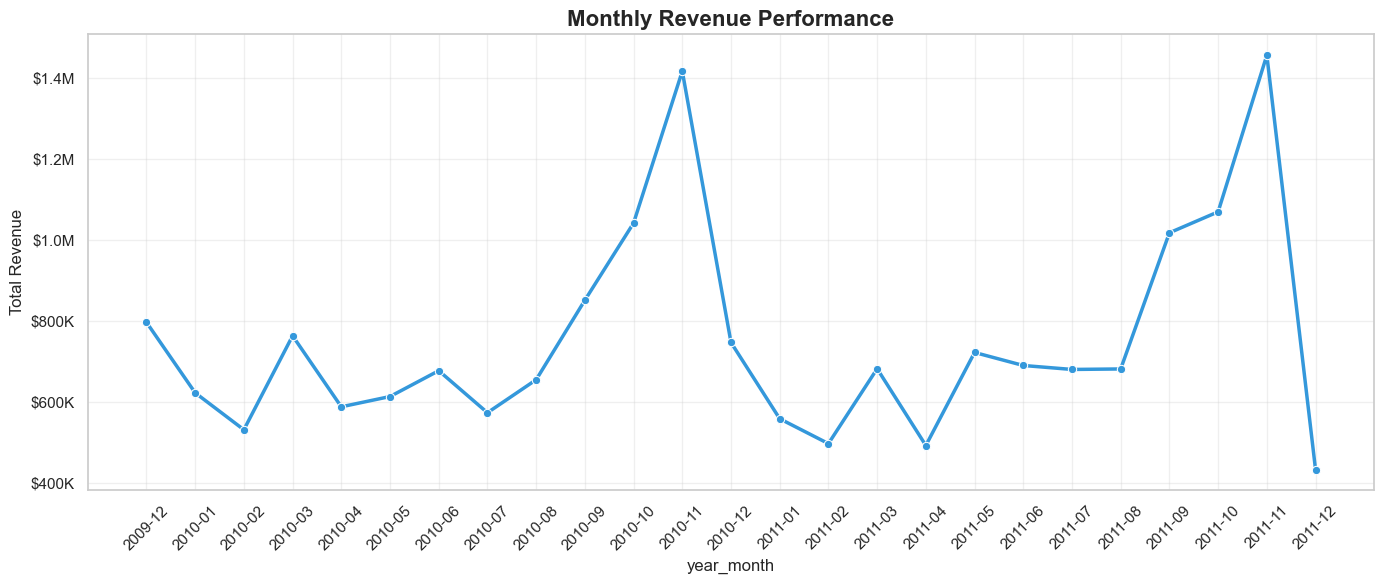

In [ ]:
monthly_data = df.groupby('year_month')['total_revenue'].sum().reset_index()

plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=monthly_data, x='year_month', y='total_revenue', marker='o', color='#3498db', linewidth=2.5)

import matplotlib.ticker as ticker

def format_pay(x, pos):
    if x >= 1_000_000:
        return f'${x*1e-6:.1f}M'
    elif x >= 1_000:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_pay))

# 3. Clean up the labels
plt.title('Monthly Revenue Performance', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Top 10 'Cash Cow' Products

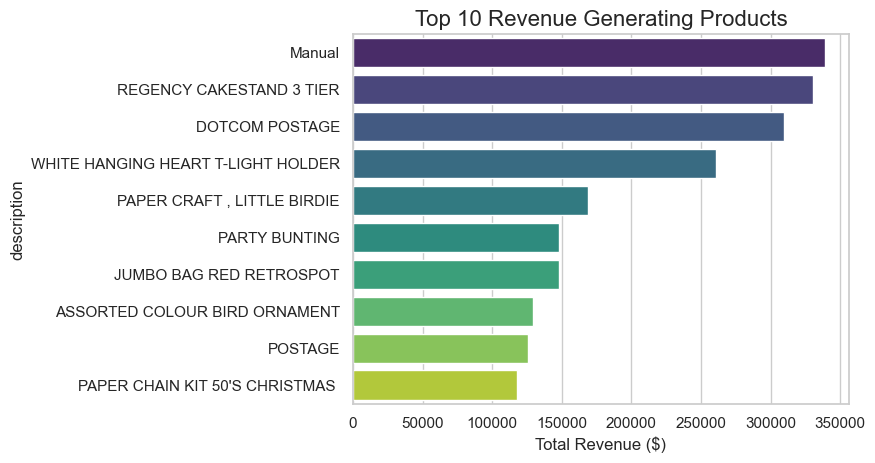

In [ ]:
top_products = df[df['is_cancelled'] == 0].groupby('description')['total_revenue'].sum().sort_values(ascending=False).head(10).reset_index()

# Plot
sns.barplot(data=top_products, x='total_revenue', y='description', hue='description', palette='viridis', legend=False)
plt.title('Top 10 Revenue Generating Products', fontsize=16)
plt.xlabel('Total Revenue ($)')
plt.show()

In [ ]:
product_stats = df.groupby('description').agg(
    total_sold=('quantity', lambda x: x[x > 0].sum()),
    total_returned=('quantity', lambda x: x[x < 0].abs().sum())
)

product_stats = product_stats[product_stats['total_sold'] > 500]

In [ ]:
product_stats['return_rate'] = (product_stats['total_returned'] / product_stats['total_sold']) * 100

In [ ]:
toxic_assets = product_stats.sort_values(by='return_rate', ascending=False).head(10).reset_index()

In [ ]:
garbage_terms = ['check', '?', 'wrongly coded', 'incorrectly', 'damages', 'samples']

In [ ]:
import re

# 1. Use re.escape to automatically put a backslash (\) before '?' and other special chars
garbage_pattern = '|'.join([re.escape(term) for term in garbage_terms])

clean_toxic = toxic_assets[
    (~toxic_assets['description'].str.lower().str.contains(garbage_pattern, na=False)) &
    (toxic_assets['return_rate'] <= 100)
]

### Toxic Assets (Return Rate Analysis)

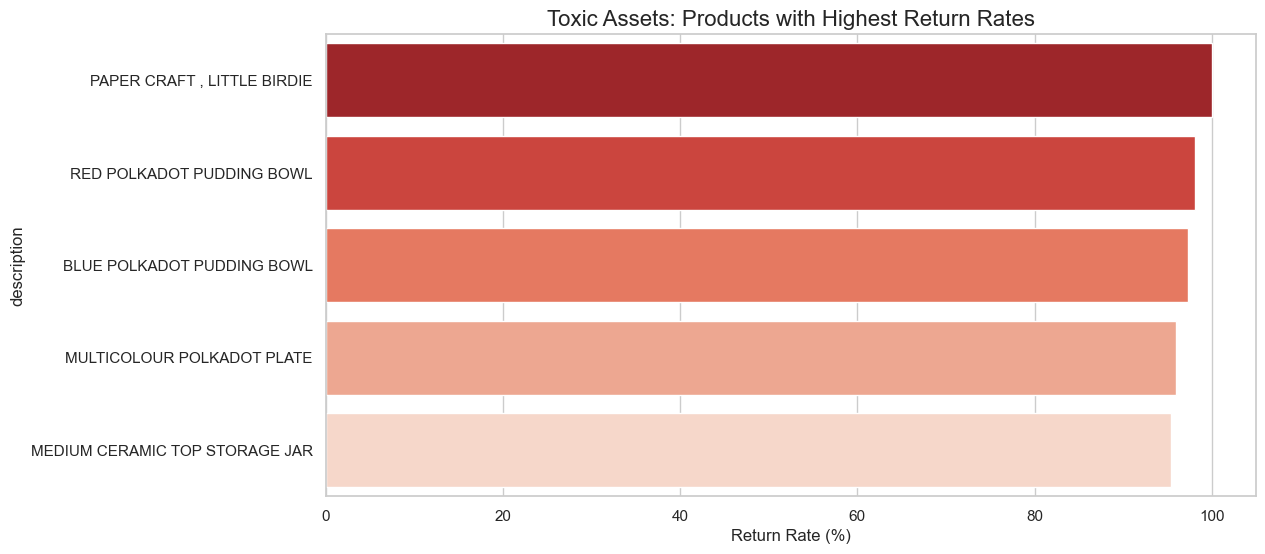

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=clean_toxic, 
    x='return_rate', 
    y='description', 
    hue='description', 
    palette='Reds_r', 
    legend=False
)

plt.title('Toxic Assets: Products with Highest Return Rates', fontsize=16)
plt.xlabel('Return Rate (%)')
plt.show()

In [ ]:
df['day_name'] = df['invoicedate'].dt.day_name()
df['hour'] = df['invoicedate'].dt.hour

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 3. Create a pivot table for the heatmap (Counting unique invoices)
heatmap_data = df.groupby(['day_name', 'hour'])['invoice'].nunique().unstack()

# 4. Reorder the rows so they aren't alphabetical
heatmap_data = heatmap_data.reindex(days_order)


✅ Heatmap data prepared.


### Peak-Hour Heatmap

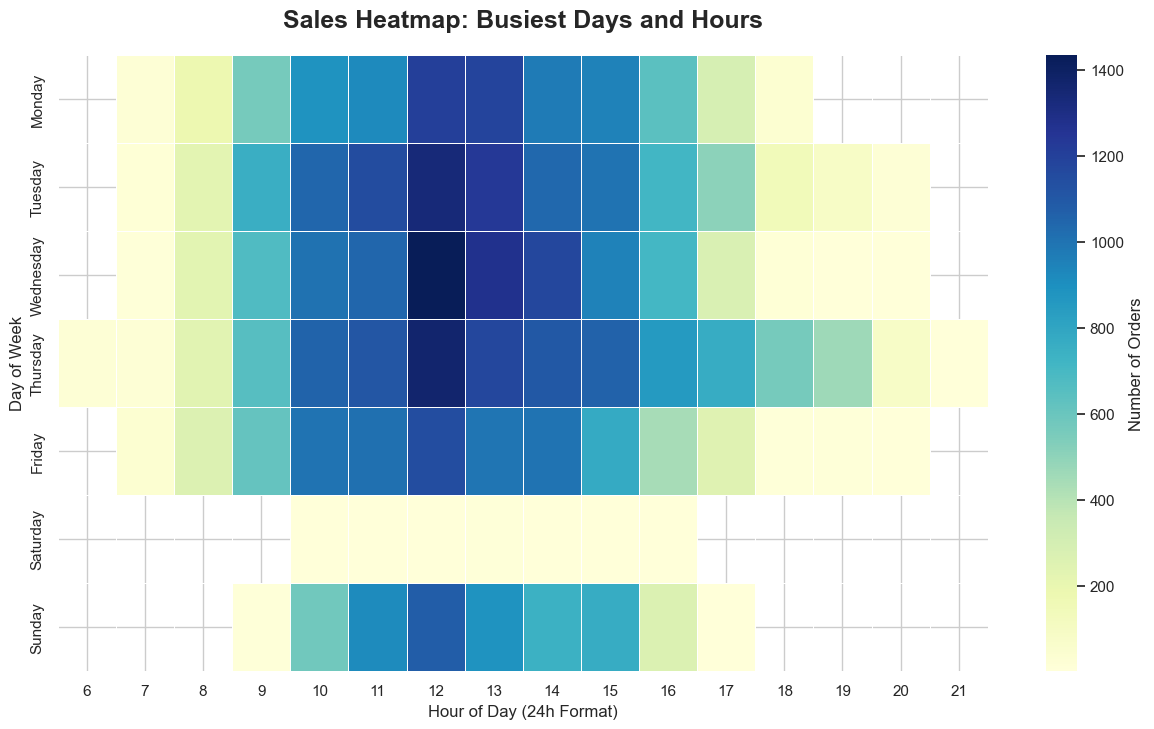

In [ ]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    heatmap_data, 
    cmap='YlGnBu', 
    annot=False,    
    linewidths=.5, 
    cbar_kws={'label': 'Number of Orders'}
)

plt.title('Sales Heatmap: Busiest Days and Hours', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Hour of Day (24h Format)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.show()

#### RFM ANALYSIS

In [ ]:
import datetime as dt

# 1. Define the reference date (Snapshot date)
latest_date = df['invoicedate'].max() + dt.timedelta(days=1)

# 2. Aggregate data by Customer
rfm = df.groupby('customer_id').agg({
    'invoicedate': lambda x: (latest_date - x.max()).days, # Recency
    'invoice': 'nunique',                                 # Frequency
    'total_revenue': 'sum'                                # Monetary
})

# 3. Rename columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Filter out customers with 0 or negative revenue (returns only)
rfm = rfm[rfm['Monetary'] > 0]

print(f"✅ RFM Table Created for {len(rfm):,} unique customers.")
rfm.head()

✅ RFM Table Created for 5,841 unique customers.


,Recency,Frequency,Monetary
customer_id,,,
0.0,1,4477,2565542.41
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,5,4404.54
12350.0,310,1,334.40


In [ ]:
# Create 1-5 scores for each metric
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores into a single RFM Segment string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# Mapping Segments to Human-Readable Labels
segs = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose Them',
    r'3[1-2]': 'About To Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm['Segment'] = rfm['RFM_Segment'].replace(segs, regex=True)

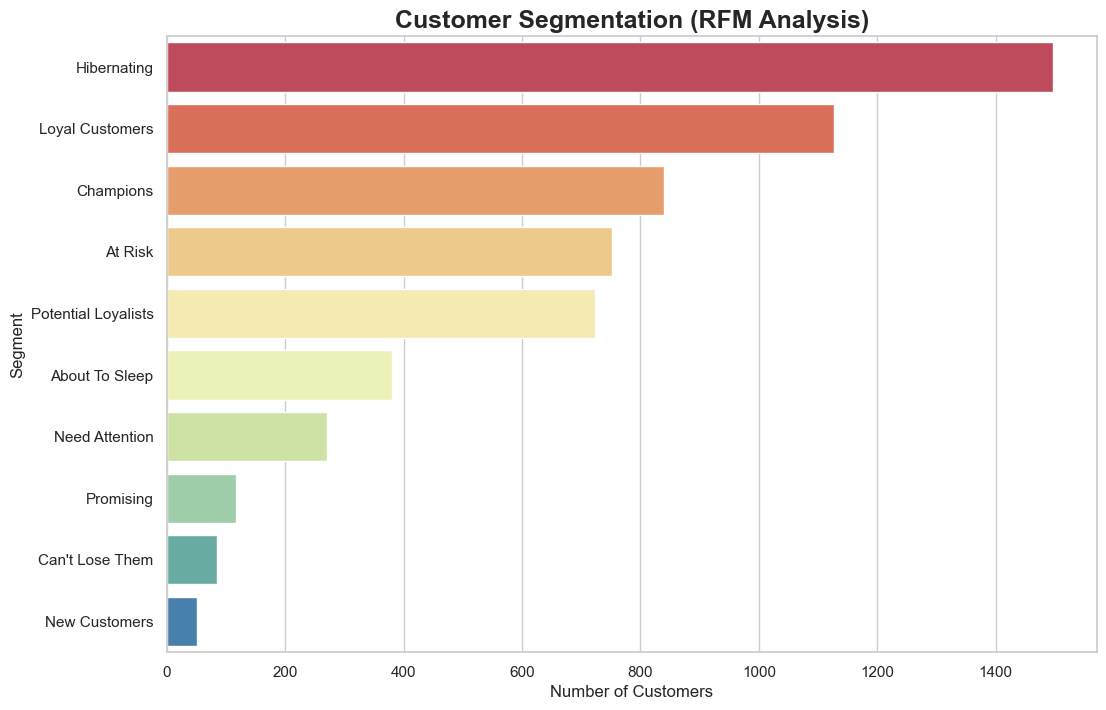

In [ ]:
plt.figure(figsize=(12, 8))

# Calculate the size of each segment
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

sns.barplot(data=segment_counts, x='Count', y='Segment', hue='Segment', palette='Spectral', legend=False)

plt.title('Customer Segmentation (RFM Analysis)', fontsize=18, fontweight='bold')
plt.xlabel('Number of Customers')
plt.show()